# Preprocessing Pipeline Inspection
This notebook isolates the feature extraction steps (Keypoints, Point Clouds, Alignment, and Similarity) to help diagnose noisy data leading to poor MLP performance on the test set.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import quaternion

# Ensure local modules are accessible
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from modules.rgbd_similarity import RGBDSimilarity
from modules.feature_based_point_cloud_registration import FeatureBasedPointCloudRegistration

/home/rodriguez/miniconda3/envs/habitat/lib/python3.9/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/home/rodriguez/Documents/GitHub/rpi_nav/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [2]:
## 1. Define the Real-World Wrapper
# The base FeatureBasedPointCloudRegistration does not accept intrinsics directly.
# We must use the wrapper defined in your original pipeline.
class RealFeatureBasedPointCloudRegistration(FeatureBasedPointCloudRegistration):
    def __init__(
        self, config: dict, device: str, id_run: int,
        feature_nav_conf: str = "LightGlue", feature_mode: str = "mnn",
        topological_map: bool = False, manual_operation: bool = False,
        fx: float = 610.1170, fy: float = 610.2250, cx: float = 323.7142, cy: float = 237.8927,
        depth_scale: float = 1e-3, invalid_depth_value: float = 0.0
    ):
        super().__init__(
            config=config, device=device, id_run=id_run,
            feature_nav_conf=feature_nav_conf, feature_mode=feature_mode,
            topological_map=topological_map, manual_operation=manual_operation
        )
        self.fx = float(fx)
        self.fy = float(fy)
        self.cx = float(cx)
        self.cy = float(cy)
        self.depth_scale = float(depth_scale)
        self.invalid_depth_value = float(invalid_depth_value)

    def generate_pc_in_cam_ref_frame(self, depth_img: np.ndarray, T_cam_world=None) -> np.ndarray:
        depth = depth_img.astype(np.float64) * self.depth_scale
        h, w = depth.shape
        u, v = np.meshgrid(np.arange(w, dtype=np.float64), np.arange(h, dtype=np.float64))
        Z = depth
        X = (u - self.cx) * Z / self.fx
        Y = (v - self.cy) * Z / self.fy
        valid = np.isfinite(Z) & (Z > self.invalid_depth_value)
        X[~valid] = np.nan
        Y[~valid] = np.nan
        Z[~valid] = np.nan
        ones = np.ones_like(Z, dtype=np.float64)
        return np.stack([X, Y, Z, ones], axis=0).reshape(4, -1)

    def get_ipc_from_pc(self, pc_cam: np.ndarray, kp_cam: np.ndarray, h: int, w: int) -> np.ndarray:
        kp = np.asarray(kp_cam, dtype=np.float64)
        xs = np.clip(np.round(kp[:, 0]).astype(int), 0, w - 1)
        ys = np.clip(np.round(kp[:, 1]).astype(int), 0, h - 1)
        cam_key_id = ys * w + xs
        ipc_cam_h = pc_cam[:, cam_key_id]
        return ipc_cam_h[:3].T

    def _filter_valid_depth_correspondences(self, kp_source, kp_target, source_depth, target_depth):
        hs, ws = source_depth.shape[:2]
        ht, wt = target_depth.shape[:2]
        ks, kt = np.asarray(kp_source, dtype=np.float64), np.asarray(kp_target, dtype=np.float64)
        xs, ys = np.clip(np.round(ks[:, 0]).astype(int), 0, ws - 1), np.clip(np.round(ks[:, 1]).astype(int), 0, hs - 1)
        xt, yt = np.clip(np.round(kt[:, 0]).astype(int), 0, wt - 1), np.clip(np.round(kt[:, 1]).astype(int), 0, ht - 1)
        ds, dt = source_depth[ys, xs], target_depth[yt, xt]
        valid = np.isfinite(ds) & np.isfinite(dt) & (ds > self.invalid_depth_value) & (dt > self.invalid_depth_value)
        return ks[valid], kt[valid]

    def compute_relative_pose(self, source_color, source_depth, target_color, target_depth):
        kp_source, kp_target = self.feature_nav.compute_matches(source_color, target_color)
        if len(kp_source) < 4 or len(kp_target) < 4: return True, None, None, None, None
        kp_source, kp_target = self._filter_valid_depth_correspondences(kp_source, kp_target, source_depth, target_depth)
        if len(kp_source) < 4 or len(kp_target) < 4: return True, None, None, None, None
        hs, ws = source_depth.shape[:2]
        ht, wt = target_depth.shape[:2]
        source_pc_h = self.generate_pc_in_cam_ref_frame(source_depth)
        target_pc_h = self.generate_pc_in_cam_ref_frame(target_depth)
        ipc_source = self.get_ipc_from_pc(source_pc_h, kp_source, hs, ws)
        ipc_target = self.get_ipc_from_pc(target_pc_h, kp_target, ht, wt)
        valid3d = np.isfinite(ipc_source).all(axis=1) & np.isfinite(ipc_target).all(axis=1)
        ipc_source, ipc_target = ipc_source[valid3d], ipc_target[valid3d]
        if len(ipc_source) < 4 or len(ipc_target) < 4: return True, None, None, None, None
        rmse, transformed_ipc_source, est_T = self.execute_SVD_registration(ipc_source, ipc_target)
        R, t = est_T[:3, :3], est_T[:3, 3]
        q = quaternion.from_rotation_matrix(R)
        return False, q, rmse, t, est_T

In [3]:
## 2. Setup & Load Data
dataset_path = PROJECT_ROOT / "visual_paths" / "Cubiculo_13-Laboratorio_I"

# Adjust indices here to test different pairs
idx_sim = "0000"
idx_mem = "0000"

source_rgb = np.array(Image.open(dataset_path / f"Simulation/rgb/rgb_{idx_sim}.png").convert("RGB"))
source_depth = np.array(Image.open(dataset_path / f"Simulation/depth/depth_{idx_sim}.png"))

target_rgb = np.array(Image.open(dataset_path / f"visual_memory-1stdev/rgb/rgb_{idx_mem}.png").convert("RGB"))
target_depth = np.array(Image.open(dataset_path / f"visual_memory-1stdev/depth/depth_{idx_mem}.png"))

# Camera Intrinsics & Scaling
fx, fy = 610.1170, 610.2250
cx, cy = 323.7142, 237.8927
depth_scale = 1e-3

Number of keypoints in Source: 159
Number of keypoints in Target: 159


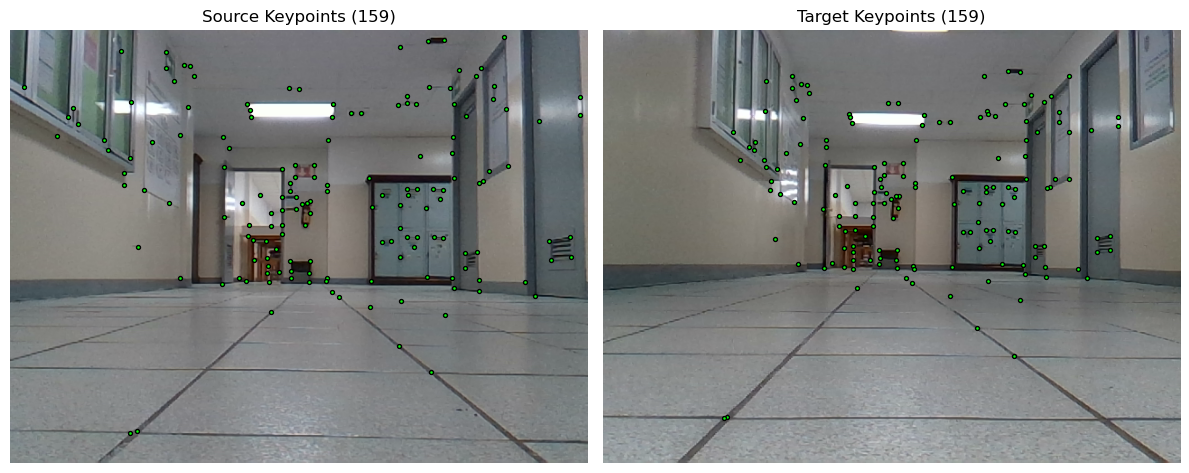

In [4]:
%matplotlib inline
import sys
import numpy as np
import matplotlib.pyplot as plt
## Step 1: Keypoint Detection & Matching
reg = RealFeatureBasedPointCloudRegistration(
    config={}, device="cuda", id_run=0, feature_mode="mnn",
    fx=fx, fy=fy, cx=cx, cy=cy, depth_scale=depth_scale
)

kp_source, kp_target = reg.feature_nav.compute_matches(source_rgb, target_rgb)

print(f"Number of keypoints in Source: {len(kp_source)}")
print(f"Number of keypoints in Target: {len(kp_target)}")
# Plotting in a single image with subplots for easier comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(source_rgb)
axes[0].scatter(np.array(kp_source)[:, 0], np.array(kp_source)[:, 1], c="lime", s=8, edgecolors="black")
axes[0].set_title(f"Source Keypoints ({len(kp_source)})")
axes[0].axis("off")

axes[1].imshow(target_rgb)
axes[1].scatter(np.array(kp_target)[:, 0], np.array(kp_target)[:, 1], c="lime", s=8, edgecolors="black")
axes[1].set_title(f"Target Keypoints ({len(kp_target)})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

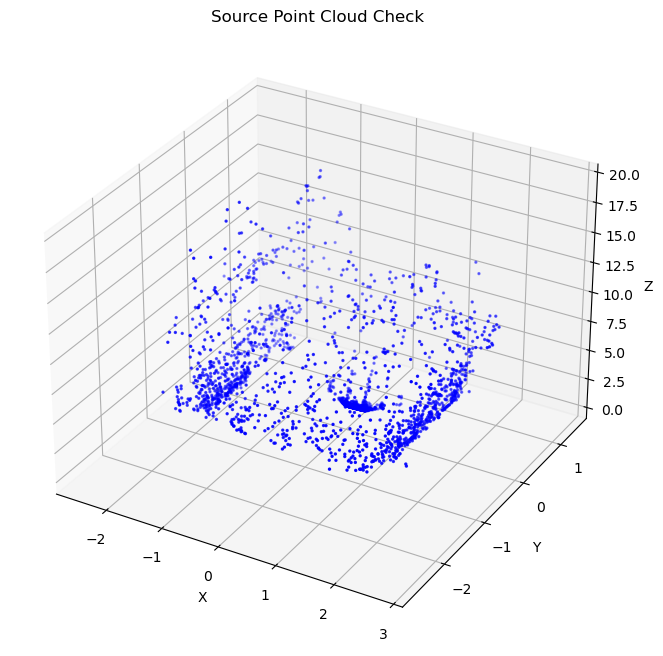

In [5]:
## Step 2: Point Cloud Generation
def generate_pc(depth):
    h, w = depth.shape
    u, v = np.meshgrid(np.arange(w), np.arange(h))
    Z = depth.astype(float) * depth_scale
    X = (u - cx) * Z / fx
    Y = (v - cy) * Z / fy
    
    valid = (Z > 0) & np.isfinite(Z)
    X, Y, Z = X[valid], Y[valid], Z[valid]
    
    # Point clouds are blue in v2
    Cs = np.zeros((len(X), 3))
    Cs[:, 2] = 1.0 
    return X, Y, Z, Cs

Xs, Ys, Zs, Cs = generate_pc(source_depth)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
# Subsampling heavily (step=100) to prevent matplotlib from freezing
step = 100
ax.scatter(Xs[::step], Ys[::step], Zs[::step], c=Cs[::step], s=2)
ax.set_title("Source Point Cloud Check")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
plt.show()

In [6]:
## Step 3 & 4: Alignment and Visual Similarity
try:
    bot_lost, q, rmse, t, est_T = reg.compute_relative_pose(source_rgb, source_depth, target_rgb, target_depth)
    print("--- Alignment Results ---")
    print(f"Bot Lost: {bot_lost}")
    print(f"RMSE:     {rmse:.5f}")
    print(f"Trans(x,y,z): {t}")
except Exception as e:
    print(f"Alignment failed: {e}")

print("\n--- Similarity Results ---")
sim_model = RGBDSimilarity(device="cuda", threshold=0.95)
score = sim_model.compute_image_similarity(source_rgb, source_depth, target_rgb, target_depth)
print(f"RGB-D Similarity Score: {score:.4f}")

--- Alignment Results ---
Bot Lost: False
RMSE:     1.06393
Trans(x,y,z): [0.09746094 0.02261201 1.57899707]

--- Similarity Results ---


/home/rodriguez/miniconda3/envs/habitat/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/rodriguez/miniconda3/envs/habitat/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/rodriguez/Documents/GitHub/rpi_nav/modules/rgbd_similarity.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (

RGB-D Similarity Score: 0.9026


/home/rodriguez/Documents/GitHub/rpi_nav/model/rd3d_plus.py:288: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  pred_s = F.upsample(pred_s, size=size, mode='bilinear', align_corners=True)


In [7]:
import open3d as o3d

# 1. Generate target point cloud
Xt, Yt, Zt, _ = generate_pc(target_depth)

# 2. Convert to Open3D format
pcd_source = o3d.geometry.PointCloud()
pcd_source.points = o3d.utility.Vector3dVector(np.column_stack((Xs, Ys, Zs)))
pcd_source.paint_uniform_color([1, 0, 0]) # Paint Source RED
# print the number of points in source and target for debugging
print(f"Source Point Cloud: {len(pcd_source.points)} points")

pcd_target = o3d.geometry.PointCloud()
pcd_target.points = o3d.utility.Vector3dVector(np.column_stack((Xt, Yt, Zt)))
pcd_target.paint_uniform_color([0, 0, 1]) # Paint Target BLUE
print(f"Target Point Cloud: {len(pcd_target.points)} points")

# 3. Apply the estimated transformation matrix (est_T) from Step 3
pcd_source_transformed = pcd_source.transform(est_T)

# 4. Visualize
print("Red: Transformed Source | Blue: Target")
o3d.visualization.draw_geometries([pcd_source_transformed, pcd_target])

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Source Point Cloud: 223478 points
Target Point Cloud: 230026 points
Red: Transformed Source | Blue: Target


In [13]:
## Step X: Visualize keypoint-based point clouds with Open3D
## Blue   = source key pc
## Red    = initial target key pc
## Orange = transformed target key pc (after est_T)

import numpy as np
import open3d as o3d

# --- 1) Ensure keypoint matches exist ---
if "kp_source" not in globals() or "kp_target" not in globals():
    kp_source, kp_target = reg.feature_nav.compute_matches(source_rgb, target_rgb)

# --- 2) Keep only correspondences with valid depth ---
kp_source_valid, kp_target_valid = reg._filter_valid_depth_correspondences(
    kp_source, kp_target, source_depth, target_depth
)

print(f"Matched keypoints            : {len(kp_source)}")
print(f"Valid depth correspondences  : {len(kp_source_valid)}")

# --- 3) Generate full homogeneous point clouds from depth if absent ---
if "source_pc_h" not in globals():
    source_pc_h = reg.generate_pc_in_cam_ref_frame(source_depth)

if "target_pc_h" not in globals():
    target_pc_h = reg.generate_pc_in_cam_ref_frame(target_depth)

# --- 4) Extract ONLY the LightGlue keypoint 3D points ---
hs, ws = source_depth.shape[:2]
ht, wt = target_depth.shape[:2]

ipc_source = reg.get_ipc_from_pc(source_pc_h, kp_source_valid, hs, ws)  # source key pc
ipc_target = reg.get_ipc_from_pc(target_pc_h, kp_target_valid, ht, wt)  # initial target key pc

# Remove any remaining non-finite 3D points
valid3d = np.isfinite(ipc_source).all(axis=1) & np.isfinite(ipc_target).all(axis=1)
ipc_source = ipc_source[valid3d]
ipc_target = ipc_target[valid3d]

print(f"Finite 3D keypoints kept     : {len(ipc_source)}")

# --- 5) Ensure transformation exists; compute it if needed ---
if "est_T" not in globals() or est_T is None:
    bot_lost, q, rmse, t, est_T = reg.compute_relative_pose(
        source_rgb, source_depth, target_rgb, target_depth
    )
    print(f"Computed est_T | bot_lost={bot_lost}, rmse={rmse}, t={t}")

if est_T is None:
    raise ValueError("est_T is None. Relative pose estimation failed, so transformed key pc cannot be visualized.")

# --- 6) Apply transform to source key pc ---
print(f"Applying transformation to source key pc with est_T:\n{est_T}")
ipc_source_h = np.hstack([ipc_source, np.ones((ipc_source.shape[0], 1), dtype=np.float64)])
ipc_source_transformed = (est_T @ ipc_source_h.T).T[:, :3]

# --- 7) Build Open3D point clouds ---
pcd_source_key = o3d.geometry.PointCloud()
pcd_source_key.points = o3d.utility.Vector3dVector(ipc_source)
pcd_source_key.paint_uniform_color([0.0, 0.0, 1.0])   # blue

pcd_target_key = o3d.geometry.PointCloud()
pcd_target_key.points = o3d.utility.Vector3dVector(ipc_target)
pcd_target_key.paint_uniform_color([1.0, 0.0, 0.0])   # red

pcd_source_key_transformed = o3d.geometry.PointCloud()
pcd_source_key_transformed.points = o3d.utility.Vector3dVector(ipc_source_transformed)
pcd_source_key_transformed.paint_uniform_color([1.0, 0.5, 0.0])  # orange

# Optional coordinate frame
frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.1)

print(f"Source key pc points         : {len(pcd_source_key.points)}")
print(f"Initial target key pc points : {len(pcd_target_key.points)}")
print(f"Transformed key pc points    : {len(pcd_source_key_transformed.points)}")

# --- 8) Visualize ---
print("Blue = source key pc | Red = initial target key pc | Orange = transformed source key pc")
o3d.visualization.draw_geometries(
    [pcd_source_key, pcd_target_key, pcd_source_key_transformed, frame],
    window_name="Keypoint Point Clouds: Source / Target / Transformed Source",
    width=1280,
    height=900
)

Matched keypoints            : 159
Valid depth correspondences  : 154
Finite 3D keypoints kept     : 154
Applying transformation to source key pc with est_T:
[[ 0.999651   -0.02208349 -0.01449854  0.09746094]
 [ 0.02172292  0.999462   -0.02457276  0.02261201]
 [ 0.01503339  0.02424923  0.9995929   1.57899707]
 [ 0.          0.          0.          1.        ]]
Source key pc points         : 154
Initial target key pc points : 154
Transformed key pc points    : 154
Blue = source key pc | Red = initial target key pc | Orange = transformed source key pc
